# Curación · iteración 1: `missing` y clase equivocada, a ojo

In [84]:
import sys
from collections.abc import Sequence
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(ROOT / "src"))

In [ ]:
import ipywidgets as widgets
import soundfile
from IPython.display import Audio, display
from matplotlib.patches import Rectangle
from scipy.signal import stft

from core.config import CLEANED_DIR, RAW_DIR, RUNS_DIR
from data import cache

ITERACION = 1
RUN, KFOLD = "yolo26s_v3", "yolo26s_v3_kfold5"
# Hallazgos fuera de muestra (src/find_issues.py): train por k-fold, val y test con el modelo final
HALLAZGOS = {
    "train": RUNS_DIR / KFOLD / "hallazgos_train.csv",
    "val": RUNS_DIR / RUN / "hallazgos_val.csv",
    "test": RUNS_DIR / RUN / "hallazgos_test.csv",
}
DECISIONES = ROOT / "curation" / f"iter{ITERACION}_decisiones.csv"
# missing: predicción confiada sin ninguna fila cruda debajo; label: anotación que el modelo ve
# como otra clase. Se recorre un TIPO y una CLASE (la que ve el modelo) a la vez
TIPO = "missing"
SCORE_MIN = 0.7  # en esta iteración sólo se revisan hallazgos con score >= SCORE_MIN
N_FFT, HOP = 2048, 256
# Brillo y contraste, en dB respecto al piso de cada segmento (su mediana, que queda en 0): el
# absoluto varía 30 dB entre grabaciones. Bajar VMIN_DB aclara el fondo; acercar los dos, más contraste
VMIN_DB, VMAX_DB = -10.0, 40.0
COLUMNAS = [
    "id",
    "iteracion",
    "split",
    "recording",
    "Hallazgo",
    "species",
    "sugerencia",
    "begin_time_s",
    "end_time_s",
    "low_freq_hz",
    "high_freq_hz",
    "score",
    "pasa",
    "fecha",
]
DECISION = {True: "si", False: "no", None: "duda"}
pd.set_option("display.width", 160)

# Hallazgos: los missing sin fila cruda debajo y los label, con score >= SCORE_MIN
hallazgos = pd.concat(
    [pd.read_csv(path).assign(split=split) for split, path in HALLAZGOS.items()], ignore_index=True
)
hallazgos = hallazgos[hallazgos["Hallazgo"].isin(["missing", "label"])]
hallazgos = hallazgos[
    (hallazgos["Hallazgo"] != "missing") | (hallazgos["raw_estado"] == "sin fila")
]
hallazgos = hallazgos[hallazgos["score"] >= SCORE_MIN].reset_index(drop=True)
hallazgos["grabacion"] = [Path(r).stem for r in hallazgos["recording"]]
hallazgos["id"] = (
    hallazgos["split"]
    + "|"
    + hallazgos["Hallazgo"]
    + "|"
    + hallazgos["grabacion"]
    + "|"
    + hallazgos["species"]
    + "|"
    + hallazgos["begin_time_s"].round(3).astype(str)
    + "|"
    + hallazgos["low_freq_hz"].round(0).astype(int).astype(str)
)
assert hallazgos["id"].is_unique
# La clase que ve el modelo: la predicha en un missing, la sugerida en un label
hallazgos["clase_modelo"] = hallazgos["sugerencia"].where(
    hallazgos["Hallazgo"] == "label", hallazgos["species"]
)

# GT: todas las anotaciones de cleaned/ (primates), con la ruta de su wav en raw/
gt = pd.concat(
    [
        pd.read_csv(path, sep="\t").assign(
            audio=str((RAW_DIR / path.relative_to(CLEANED_DIR)).with_suffix(".wav"))
        )
        for path in sorted(CLEANED_DIR.glob("*/*.txt"))
        if "birds" not in path.parent.name
    ],
    ignore_index=True,
)
gt = gt[~gt["requires_review"]].reset_index(drop=True)
gt["clase"] = (gt["species"] + "/" + gt["call_type"]).replace(cache.meta().get("joined_labels", {}))


def get_next_idx(tipo: str, clase: str) -> int:
    # Índice en `hallazgos` del siguiente pendiente de `tipo` y `clase` (el de mayor score);
    # mientras no se guarde una decisión vuelve a salir el mismo
    hechos = pd.read_csv(DECISIONES)["id"] if DECISIONES.exists() else []
    de_clase = hallazgos[(hallazgos["Hallazgo"] == tipo) & (hallazgos["clase_modelo"] == clase)]
    quedan = de_clase[~de_clase["id"].isin(hechos)].sort_values("score", ascending=False)
    if quedan.empty:
        raise ValueError(f"sin pendientes de {tipo} {clase}")
    a = quedan.iloc[0]
    print(
        f"{tipo} {clase}: {len(de_clase) - len(quedan)} de {len(de_clase)} decididos · "
        f"idx {quedan.index[0]} · {a['split']} {a['grabacion']} "
        f"{a['begin_time_s']:.2f}-{a['end_time_s']:.2f} s · score {a['score']:.2f}"
    )
    return int(quedan.index[0])


def save(idx: int, flag: bool | None) -> None:
    # Escribe en el csv la decisión de `idx`: True -> si, False -> no, None -> duda. Si ya tenía
    # una, la reemplaza
    fila = hallazgos.loc[[idx]].copy()
    fila["iteracion"] = ITERACION
    fila["pasa"] = DECISION[flag]
    fila["fecha"] = datetime.now().isoformat(timespec="seconds")
    hechas = pd.read_csv(DECISIONES) if DECISIONES.exists() else pd.DataFrame(columns=COLUMNAS)
    hechas = pd.concat([hechas[hechas["id"] != fila["id"].iloc[0]], fila[COLUMNAS]])
    DECISIONES.parent.mkdir(parents=True, exist_ok=True)
    hechas.to_csv(DECISIONES, index=False)
    print(f"idx {idx} -> {DECISION[flag]} ({DECISIONES.relative_to(ROOT)})")


print(f"{len(hallazgos)} hallazgos con score >= {SCORE_MIN} · {len(gt)} anotaciones GT")
pd.crosstab(hallazgos["clase_modelo"], hallazgos["Hallazgo"])

969 hallazgos con score >= 0.7 · 17913 anotaciones GT


Hallazgo,label,missing
clase_modelo,,
aa/gc,1,14
aa/hm,0,7
aa/sc,1,4
ac/bc,0,43
ac/chc,7,12
ac/gc,2,6
ac/sc,2,8
as/bc,3,44
as/hc,10,265


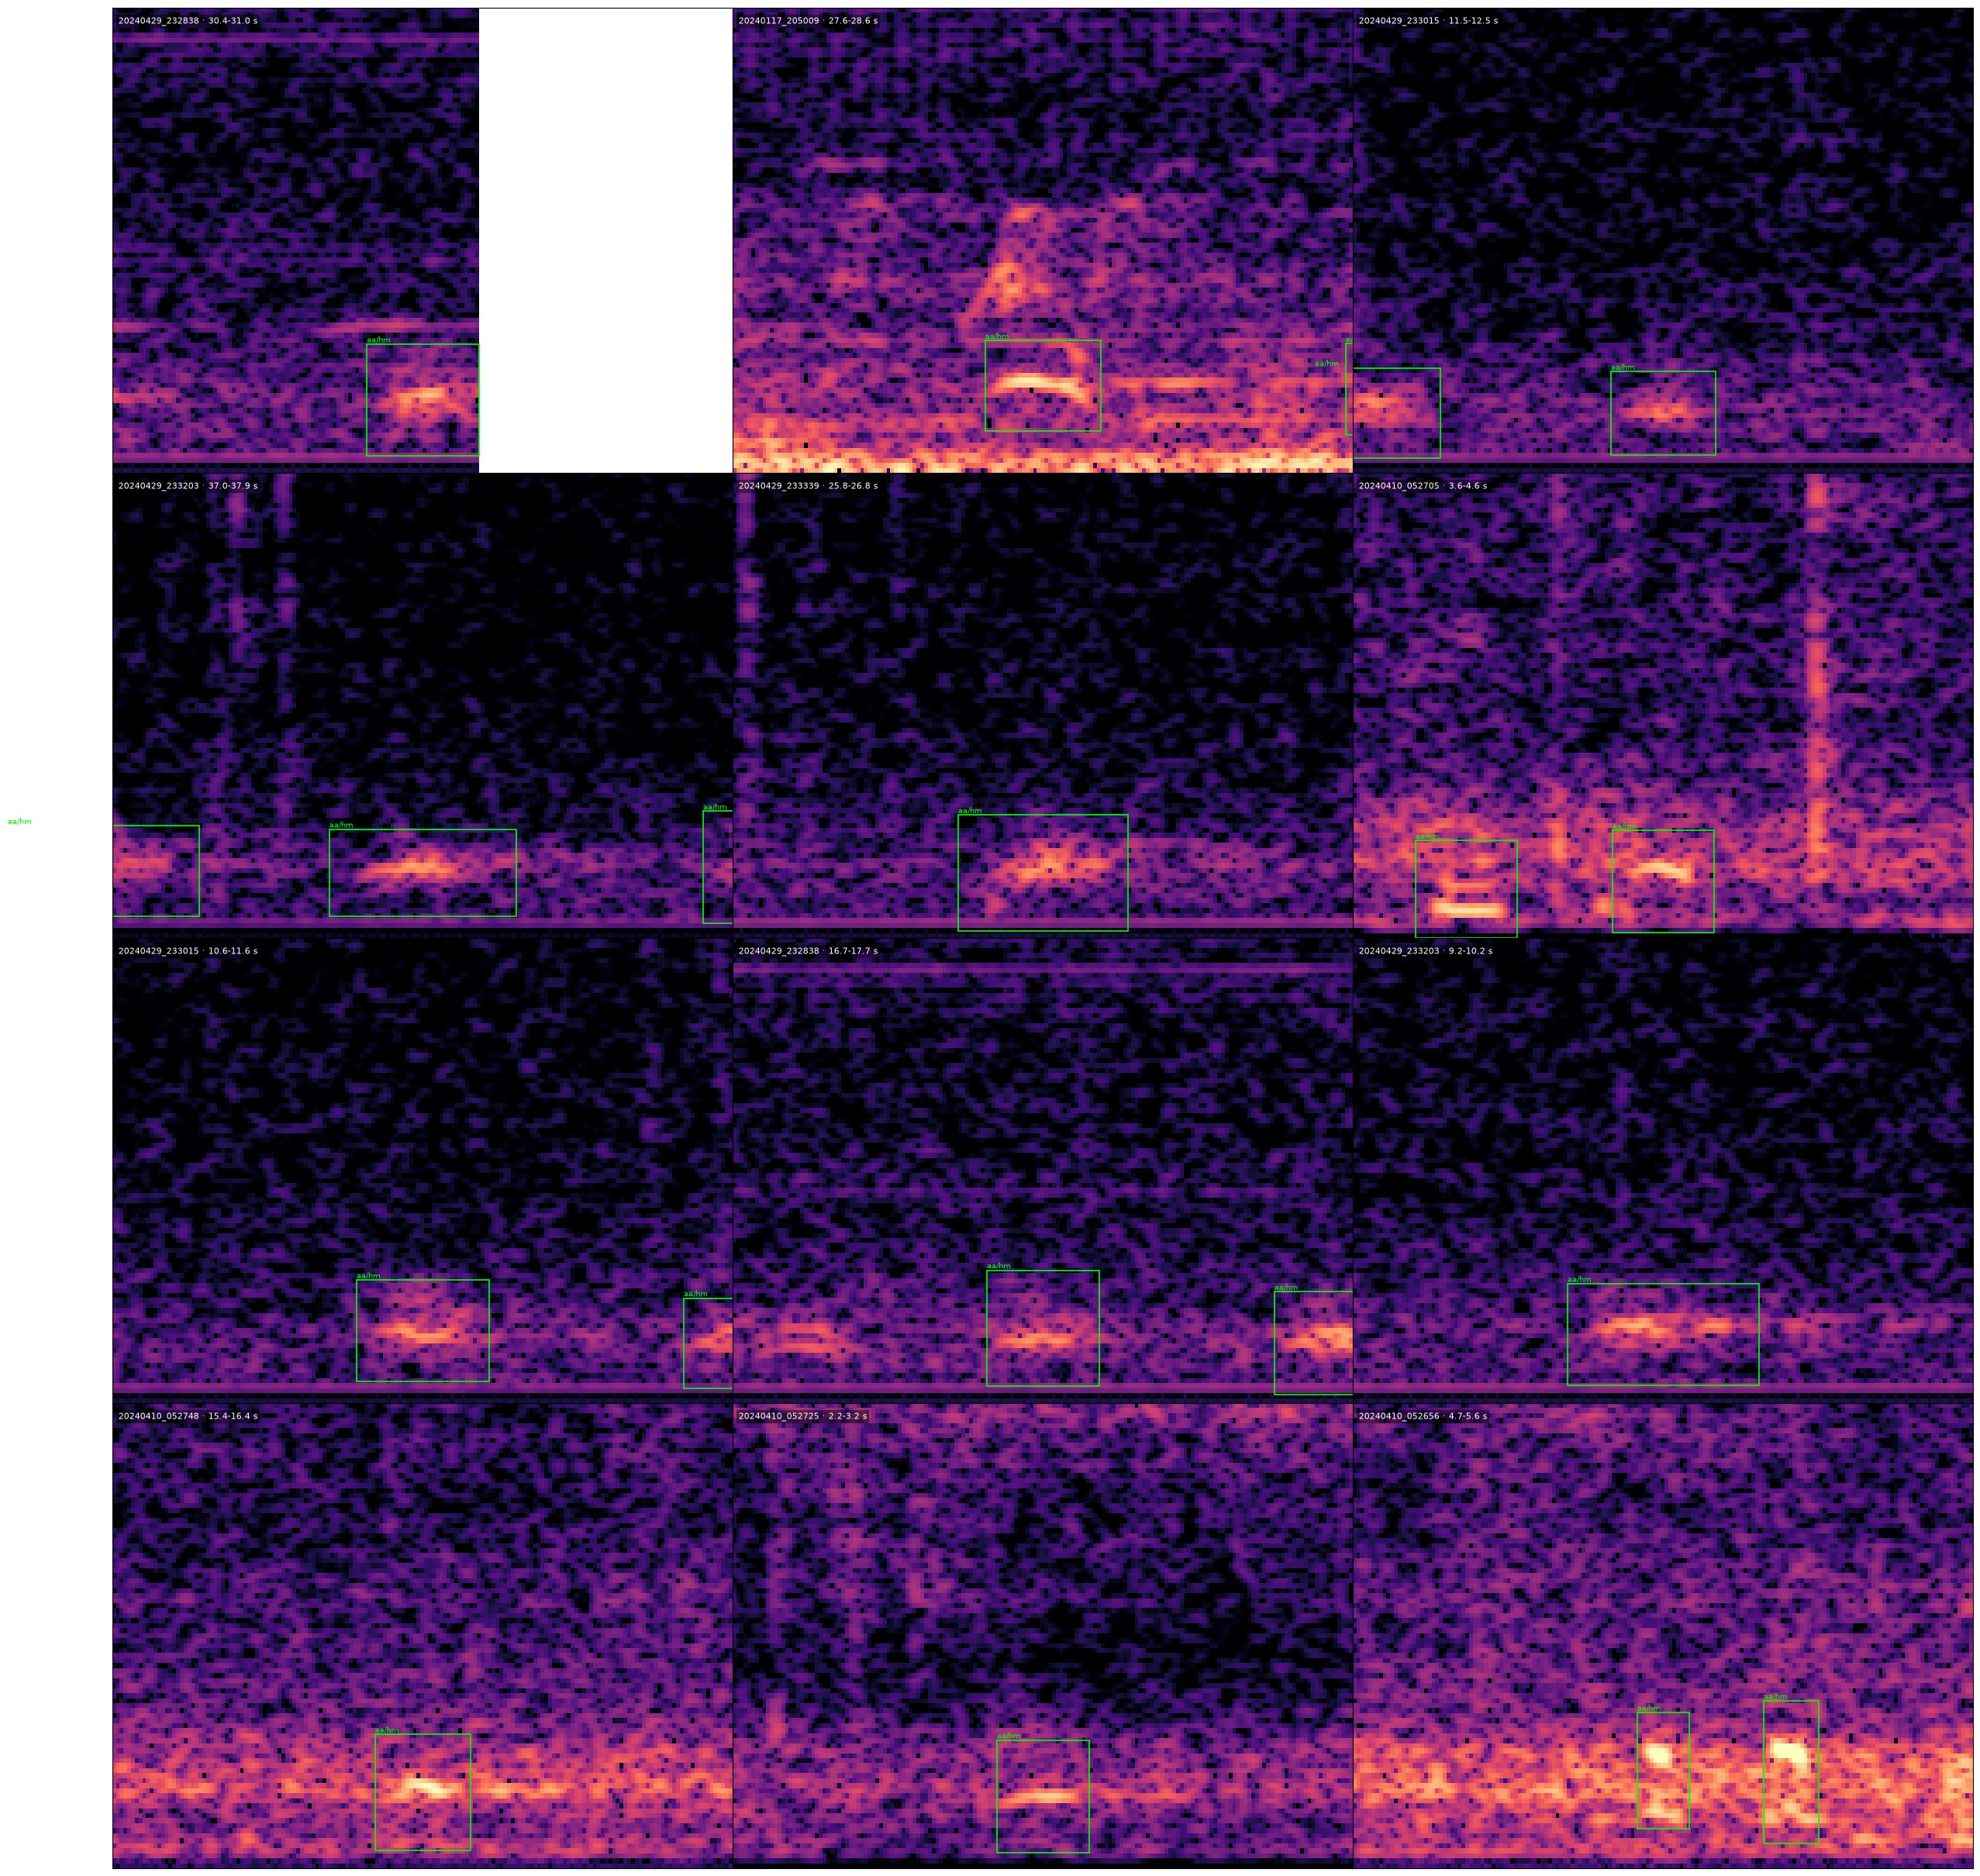

In [97]:
# GT de una clase: N_GT anotaciones al azar de CLASE, cada una con ±MARGEN_S s de audio alrededor.
# Verde la clase, blanco las demás anotaciones de la grabación que caen en la ventana
CLASE = "aa/hm"
MARGEN_S = 0.5  # audio a cada lado del centro de la anotación
rows, cols = 4, 3
N_GT = rows * cols

width = 8 * cols
height = 6 * rows

muestra = gt[gt["clase"] == CLASE].sample(N_GT)
fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(width, height),
    squeeze=False,
    sharex=True,
    sharey=True,
)
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0, hspace=0)

for ax, (_, a) in zip(axes.flat, muestra.iterrows()):
    t0 = max((a["begin_time_s"] + a["end_time_s"]) / 2 - MARGEN_S, 0.0)
    with soundfile.SoundFile(a["audio"]) as f:
        sr = f.samplerate
        f.seek(int(t0 * sr))
        y = f.read(int(2 * MARGEN_S * sr), dtype="float32", always_2d=True).mean(axis=1)
    frec, tiempo, Z = stft(
        y,
        fs=sr,
        nperseg=N_FFT,
        noverlap=N_FFT - HOP,
        boundary=None,
        padded=False,
    )
    db = 20 * np.log10(np.abs(Z) + 1e-9)
    db -= np.median(db)
    ax.imshow(
        db,
        origin="lower",
        aspect="auto",
        cmap="magma",
        extent=(tiempo[0], tiempo[-1], 0, frec[-1]),
        vmin=VMIN_DB,
        vmax=VMAX_DB,
    )
    t1 = t0 + tiempo[-1]
    en_ventana = gt[
        (gt["audio"] == a["audio"]) & (gt["end_time_s"] > t0) & (gt["begin_time_s"] < t1)
    ]
    for _, g in en_ventana.iterrows():
        color = "lime" if g["clase"] == CLASE else "white"
        ax.add_patch(
            Rectangle(
                (g["begin_time_s"] - t0, g["low_freq_hz"]),
                g["end_time_s"] - g["begin_time_s"],
                g["high_freq_hz"] - g["low_freq_hz"],
                fill=False,
                ec=color,
                lw=1.2,
            )
        )
        ax.text(
            g["begin_time_s"] - t0,
            g["high_freq_hz"],
            g["clase"],
            color=color,
            fontsize=7,
            va="bottom",
        )
    ax.set_xlim(tiempo[0], tiempo[-1])
    ax.set_ylim(0, 2000)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(
        0.01,
        0.98,
        f"{Path(a['audio']).stem} · {t0:.1f}-{t1:.1f} s",
        transform=ax.transAxes,
        color="white",
        fontsize=8,
        va="top",
        ha="left",
        bbox={"facecolor": "black", "alpha": 0.45, "pad": 2, "edgecolor": "none"},
    )

for ax in axes.flat[N_GT:]:
    ax.set_visible(False)

plt.show()

In [99]:
# Lo mismo con botones: la cola es toda la clase (decididos o no) de mayor a menor score; arranca
# en el primer pendiente. aceptar / rechazar / duda guardan y pasan al siguiente; prev / next mueven
cola = (
    hallazgos[(hallazgos["Hallazgo"] == TIPO) & (hallazgos["clase_modelo"] == CLASE)]
    .sort_values("score", ascending=False)
    .index.tolist()
)
hechas = (
    pd.read_csv(DECISIONES, index_col="id")["pasa"] if DECISIONES.exists() else pd.Series(dtype=str)
)
pos = next((i for i, idx in enumerate(cola) if hallazgos.at[idx, "id"] not in hechas.index), 0)
salida = widgets.Output()


def mostrar() -> None:
    idx = cola[pos]
    a = hallazgos.iloc[idx]
    t0 = max((a["begin_time_s"] + a["end_time_s"]) / 2 - MARGEN_S, 0.0)
    with soundfile.SoundFile(a["recording"]) as f:
        sr = f.samplerate
        f.seek(int(t0 * sr))
        y = f.read(int(2 * MARGEN_S * sr), dtype="float32", always_2d=True).mean(axis=1)
    frec, tiempo, Z = stft(y, fs=sr, nperseg=N_FFT, noverlap=N_FFT - HOP)
    db = 20 * np.log10(np.abs(Z) + 1e-9)
    db -= np.median(db)
    t1 = t0 + tiempo[-1]

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.imshow(
        db,
        origin="lower",
        aspect="auto",
        cmap="magma",
        extent=(0, tiempo[-1], 0, frec[-1]),
        vmin=VMIN_DB,
        vmax=VMAX_DB,
    )
    en_ventana = gt[
        (gt["audio"] == a["recording"]) & (gt["end_time_s"] > t0) & (gt["begin_time_s"] < t1)
    ]
    for _, g in en_ventana.iterrows():
        color = "lime" if g["clase"] == a["clase_modelo"] else "white"
        ax.add_patch(
            Rectangle(
                (g["begin_time_s"] - t0, g["low_freq_hz"]),
                g["end_time_s"] - g["begin_time_s"],
                g["high_freq_hz"] - g["low_freq_hz"],
                fill=False,
                ec=color,
                lw=1.2,
            )
        )
        ax.text(
            g["begin_time_s"] - t0,
            g["high_freq_hz"],
            g["clase"],
            color=color,
            fontsize=7,
            va="bottom",
        )
    ax.add_patch(
        Rectangle(
            (a["begin_time_s"] - t0, a["low_freq_hz"]),
            a["end_time_s"] - a["begin_time_s"],
            a["high_freq_hz"] - a["low_freq_hz"],
            fill=False,
            ec="cyan",
            ls="--",
            lw=1.8,
        )
    )
    texto = f"? {a['species']}" if TIPO == "missing" else f"{a['species']} → {a['sugerencia']}"
    ax.text(
        a["begin_time_s"] - t0,
        a["high_freq_hz"],
        f"{texto} {a['score']:.2f}",
        color="cyan",
        fontsize=8,
        va="bottom",
    )
    ax.set_xlim(0, tiempo[-1])
    ax.set_ylim(0, 2000)
    ax.set_title(
        f"idx {idx} · {a['split']} · {a['grabacion']} · segmento {t0:.2f}-{t1:.2f} s · "
        f"hallazgo {a['begin_time_s']:.2f}-{a['end_time_s']:.2f} s"
    )
    hechas = (
        pd.read_csv(DECISIONES, index_col="id")["pasa"]
        if DECISIONES.exists()
        else pd.Series(dtype=str)
    )
    with salida:
        salida.clear_output(wait=True)
        print(
            f"{pos + 1} de {len(cola)} en {TIPO} {CLASE} · decisión: {hechas.get(a['id'], 'pendiente')} · "
            f"pendientes: {sum(hallazgos.at[i, 'id'] not in hechas.index for i in cola)}"
        )
        plt.show()
        display(Audio(y, rate=sr))


def mover(paso: int) -> None:
    global pos
    pos = min(max(pos + paso, 0), len(cola) - 1)
    mostrar()


def decidir(flag: bool | None) -> None:
    with salida:
        save(cola[pos], flag)
    mover(+1)


botones = [
    widgets.Button(description="◀ prev"),
    widgets.Button(description="aceptar", button_style="success"),
    widgets.Button(description="rechazar", button_style="danger"),
    widgets.Button(description="duda", button_style="warning"),
    widgets.Button(description="next ▶"),
]
botones[0].on_click(lambda _: mover(-1))
botones[1].on_click(lambda _: decidir(True))
botones[2].on_click(lambda _: decidir(False))
botones[3].on_click(lambda _: decidir(None))
botones[4].on_click(lambda _: mover(+1))
display(widgets.HBox(botones), salida)
mostrar()

Output()

In [ ]:
# Progreso por clase
hechas = (
    pd.read_csv(DECISIONES)[["id", "pasa"]]
    if DECISIONES.exists()
    else pd.DataFrame(columns=["id", "pasa"])
)
estado = hallazgos[hallazgos["Hallazgo"] == TIPO].merge(hechas, on="id", how="left")
pd.crosstab(estado["clase_modelo"], estado["pasa"].fillna("pendiente")).reindex(
    columns=["pendiente", *DECISION.values()], fill_value=0
)

In [ ]:
# Reiniciar desde cero: aparta el csv de decisiones como copia con fecha (curation/*.bak, fuera de git)
if DECISIONES.exists():
    respaldo = DECISIONES.with_name(f"{DECISIONES.stem}.{datetime.now():%Y%m%d-%H%M%S}.bak")
    DECISIONES.rename(respaldo)
    print(f"{DECISIONES.name} -> {respaldo.name}")
else:
    print("no hay decisiones guardadas")